# RNN vs LSTM vs GRU for Human Activity Recognition

## Objective

Implement and compare **Simple RNN, LSTM, and GRU** models for human activity recognition using smartphone sensor data.

The models classify six physical activities using sequential sensor measurements from the UCI Human Activity Recognition dataset.

In [1]:
# RNN vs LSTM vs GRU for Human Activity Recognition
# Dataset: UCI Human Activity Recognition Using Smartphones
# We are using smartphone sensor data to classify activities.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request
import zipfile

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# Download the dataset 
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_file = "UCI_HAR_Dataset.zip"

if not os.path.exists("UCI HAR Dataset"):
    print("Downloading dataset...")

    urllib.request.urlretrieve(url, zip_file)

    print("Extracting dataset...")

    with zipfile.ZipFile(zip_file, "r") as zip_ref:
        zip_ref.extractall(".")

    print("Done!")

else:
    print("Dataset already downloaded.")

Dataset already downloaded.


In [2]:

# Load the sensor data

# Each file contains measurements for one sensor direction.
# There are 128 readings for every activity sequence.

base_train = "UCI HAR Dataset/train/Inertial Signals/"
base_test = "UCI HAR Dataset/test/Inertial Signals/"

sensor_files = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]


# Load all 9 sensor signals
train_signals = []

for sensor in sensor_files:
    data = np.loadtxt(
        base_train + sensor + "_train.txt"
    )
    train_signals.append(data)


test_signals = []

for sensor in sensor_files:
    data = np.loadtxt(
        base_test + sensor + "_test.txt"
    )
    test_signals.append(data)


# Put all the sensor readings together.
# Shape becomes: number of samples × 128 time steps × 9 sensors

X_train = np.stack(
    train_signals,
    axis=2
)

X_test = np.stack(
    test_signals,
    axis=2
)


# Load the activity labels
y_train = np.loadtxt(
    "UCI HAR Dataset/train/y_train.txt"
).astype(int)

y_test = np.loadtxt(
    "UCI HAR Dataset/test/y_test.txt"
).astype(int)


# Dataset labels start from 1, so change them to 0-5
y_train = y_train - 1
y_test = y_test - 1


# Names of the six activities
activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]


print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (7352, 128, 9)
Testing data shape : (2947, 128, 9)


In [3]:
# Build the three models

def build_model(model_type):

    model = Sequential()

    # Each sample has 128 time steps and 9 sensor readings
    model.add(
        Input(
            shape=(
                X_train.shape[1],
                X_train.shape[2]
            )
        )
    )

    # Change only the recurrent layer to compare RNN, LSTM and GRU fairly.
    if model_type == "RNN":

        model.add(
            SimpleRNN(64)
        )

    elif model_type == "LSTM":

        model.add(
            LSTM(64)
        )

    else:

        model.add(
            GRU(64)
        )


    model.add(
        Dropout(0.3)
    )


    model.add(
        Dense(
            32,
            activation="relu"
        )
    )


    # There are 6 possible activities
    model.add(
        Dense(
            6,
            activation="softmax"
        )
    )


    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [4]:
# Train all three models

models = {}
histories = {}
results = {}
epochs = 10


# Stop early if the validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)


for model_type in ["RNN", "LSTM", "GRU"]:

    print("\n" + "=" * 50)
    print("Training:", model_type)
    print("=" * 50)

    model = build_model(model_type)

    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=64,
        validation_split=0.15,
        callbacks=[early_stopping],
        verbose=1
    )

    models[model_type] = model
    histories[model_type] = history


Training: RNN
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.4783 - loss: 1.2739 - val_accuracy: 0.4787 - val_loss: 1.1807
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6259 - loss: 0.8672 - val_accuracy: 0.5585 - val_loss: 1.0308
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6539 - loss: 0.7468 - val_accuracy: 0.5621 - val_loss: 0.9394
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.6121 - loss: 0.9359 - val_accuracy: 0.5993 - val_loss: 1.0245
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.6739 - loss: 0.7144 - val_accuracy: 0.6328 - val_loss: 0.9222
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7062 - loss: 0.6250 - val_accuracy: 0.6410 - val_loss: 0.8687
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7212 - loss: 0.5891 - val_accuracy: 0.6464 - val_loss: 0.8657
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7177 - loss: 0.6464 - val_accur

In [5]:
# Check how well each model performs

for model_type, model in models.items():

    print("\n" + "=" * 50)
    print("Results for:", model_type)
    print("=" * 50)

    # Get the probability for each of the six activities
    probabilities = model.predict(
        X_test,
        verbose=0
    )

    # Pick the activity with the highest probability
    predictions = np.argmax(
        probabilities,
        axis=1
    )


    # Calculate the main classification metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )


    results[model_type] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }


    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))


    print("\nClassification Report:")

    print(
        classification_report(
            y_test,
            predictions,
            target_names=activity_names
        )
    )


Results for: RNN
Accuracy : 0.7078
Precision: 0.7158
Recall   : 0.7078
F1 Score : 0.7075

Classification Report:
                    precision    recall  f1-score   support

           Walking       0.52      0.68      0.59       496
  Walking Upstairs       0.61      0.48      0.54       471
Walking Downstairs       0.58      0.50      0.54       420
           Sitting       0.76      0.85      0.80       491
          Standing       0.77      0.75      0.76       532
            Laying       1.00      0.92      0.96       537

          accuracy                           0.71      2947
         macro avg       0.71      0.70      0.70      2947
      weighted avg       0.72      0.71      0.71      2947


Results for: LSTM
Accuracy : 0.867
Precision: 0.8732
Recall   : 0.867
F1 Score : 0.867

Classification Report:
                    precision    recall  f1-score   support

           Walking       0.87      0.88      0.87       496
  Walking Upstairs       0.90      0.79      0.84 

In [6]:
# Put all the results into one table

results_df = pd.DataFrame(
    results
).T

print("\n")
print("=" * 60)
print("RNN vs LSTM vs GRU")
print("=" * 60)

print(
    results_df.round(4)
)



RNN vs LSTM vs GRU
      Accuracy  Precision  Recall  F1 Score
RNN     0.7078     0.7158  0.7078    0.7075
LSTM    0.8670     0.8732  0.8670    0.8670
GRU     0.8344     0.8497  0.8344    0.8324


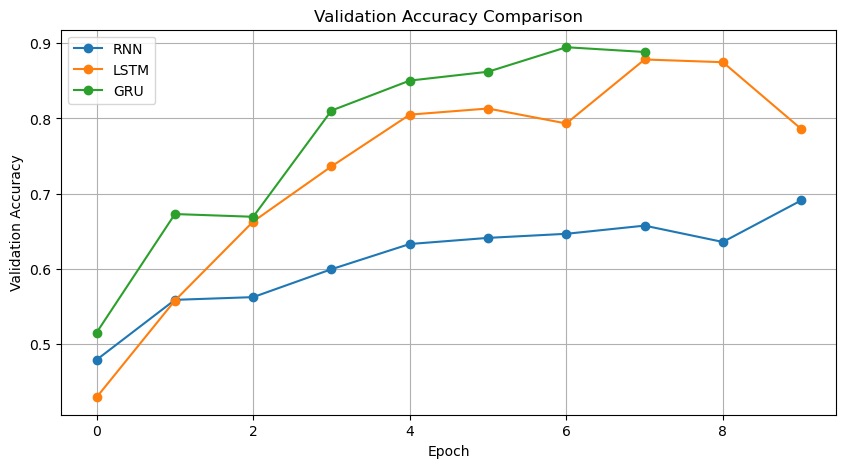

In [7]:
# Compare validation accuracy

plt.figure(figsize=(10, 5))

for model_type, history in histories.items():

    plt.plot(
        history.history["val_accuracy"],
        marker="o",
        label=model_type
    )

plt.title(
    "Validation Accuracy Comparison"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

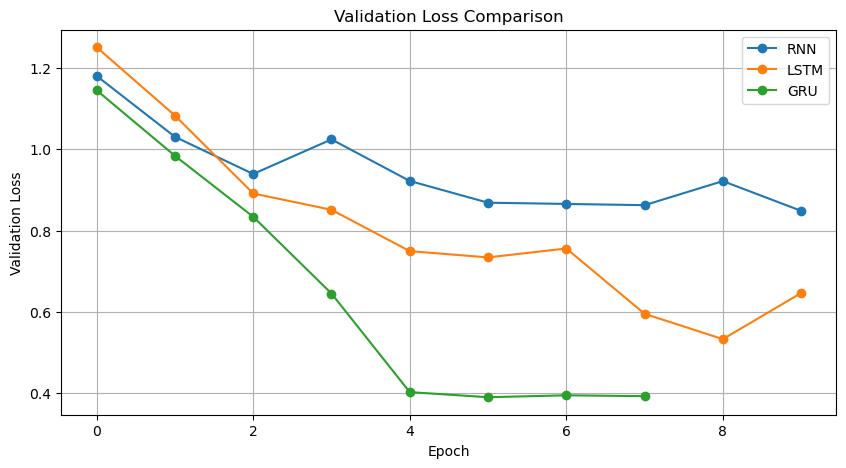

In [8]:
# Compare validation loss

plt.figure(figsize=(10, 5))

for model_type, history in histories.items():

    plt.plot(
        history.history["val_loss"],
        marker="o",
        label=model_type
    )

plt.title(
    "Validation Loss Comparison"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

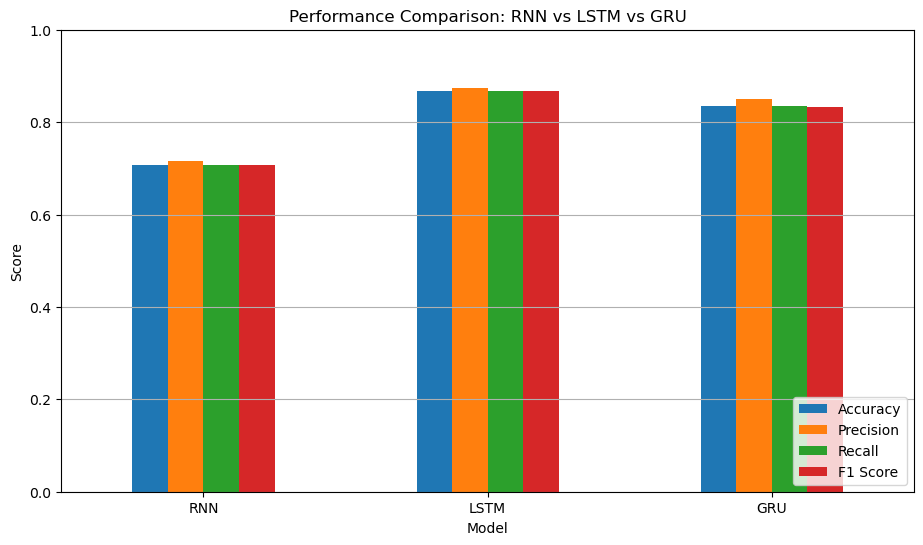

In [9]:
# Compare the final metrics

results_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Performance Comparison: RNN vs LSTM vs GRU"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.ylim(0, 1)

plt.grid(
    axis="y"
)

plt.legend(
    loc="lower right"
)

plt.show()

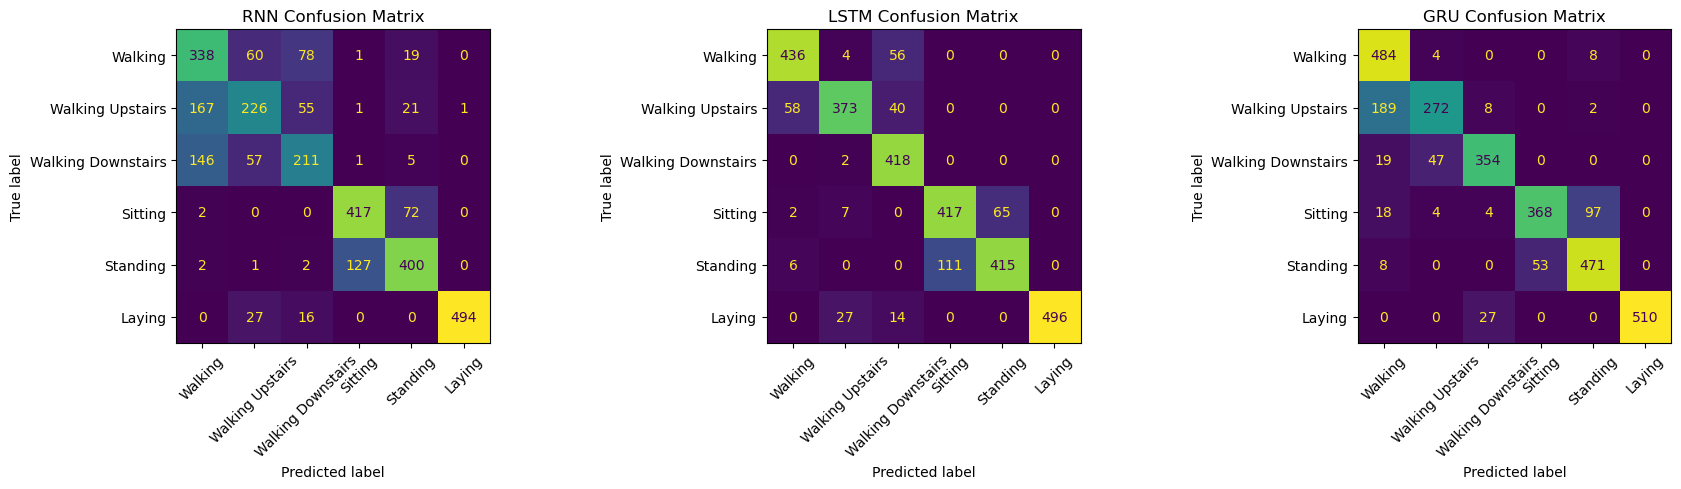

In [10]:
# Confusion matrices

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, (model_type, model) in zip(
    axes,
    models.items()
):

    probabilities = model.predict(
        X_test,
        verbose=0
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )


    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=activity_names
    )

    display.plot(
        ax=ax,
        xticks_rotation=45,
        colorbar=False
    )

    ax.set_title(
        model_type + " Confusion Matrix"
    )


plt.tight_layout()
plt.show()

In [11]:
# Final results

print("\n" + "=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

for model_type, metrics in results.items():

    print("\n" + model_type)

    print(
        "Accuracy :",
        round(metrics["Accuracy"], 4)
    )

    print(
        "Precision:",
        round(metrics["Precision"], 4)
    )

    print(
        "Recall   :",
        round(metrics["Recall"], 4)
    )

    print(
        "F1 Score :",
        round(metrics["F1 Score"], 4)
    )

print("\nMaximum epochs:", epochs)
print("All three models have been trained and compared.")


FINAL COMPARISON

RNN
Accuracy : 0.7078
Precision: 0.7158
Recall   : 0.7078
F1 Score : 0.7075

LSTM
Accuracy : 0.867
Precision: 0.8732
Recall   : 0.867
F1 Score : 0.867

GRU
Accuracy : 0.8344
Precision: 0.8497
Recall   : 0.8344
F1 Score : 0.8324

Maximum epochs: 10
All three models have been trained and compared.


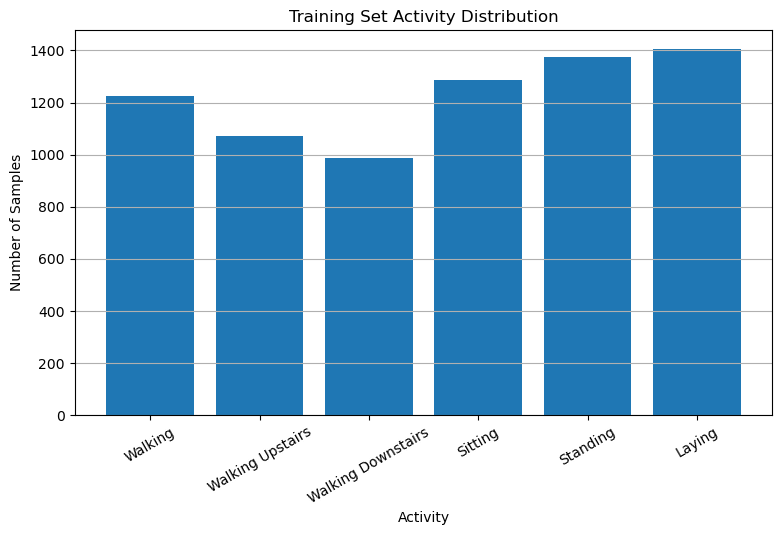

In [12]:
# Activity distribution
plt.figure(figsize=(9, 5))
counts = np.bincount(y_train)

plt.bar(activity_names, counts)
plt.title("Training Set Activity Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()


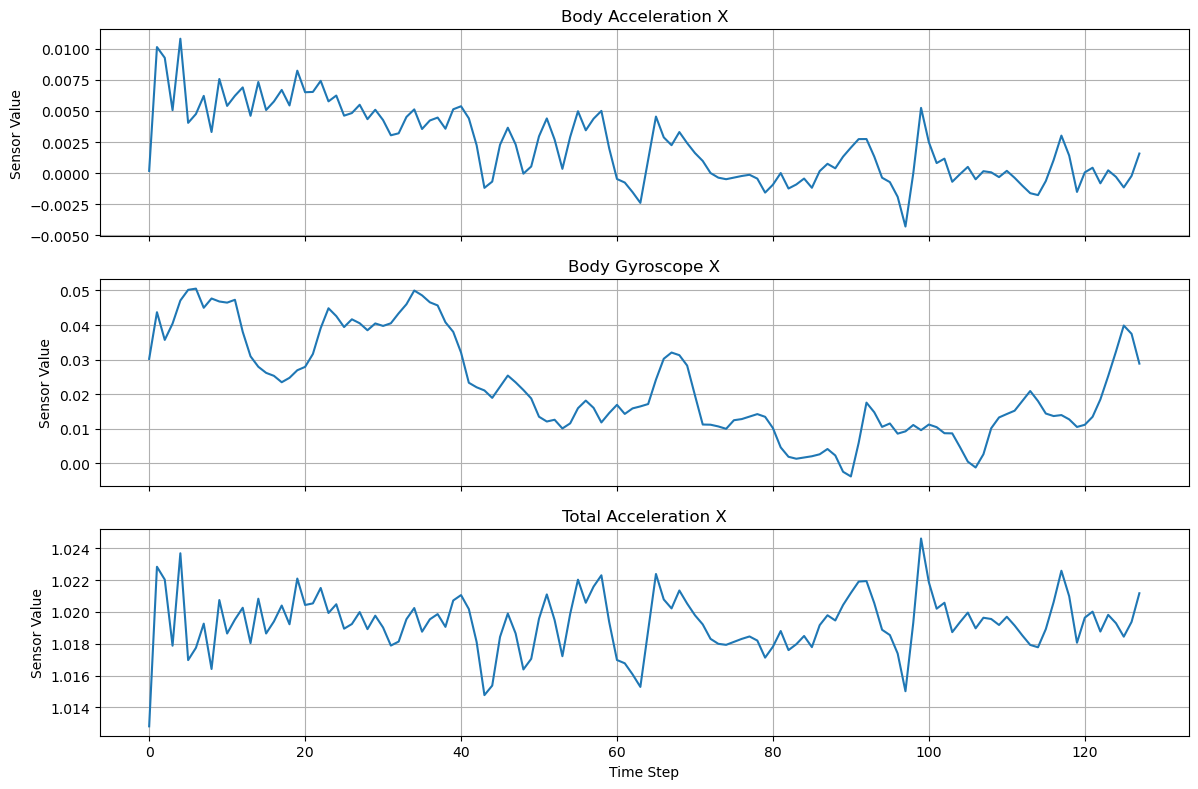

In [13]:
# Example sensor signals from the first training sequence
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

sensor_names = [
    "Body Acceleration X",
    "Body Gyroscope X",
    "Total Acceleration X"
]

sensor_indices = [0, 3, 6]

for ax, idx, name in zip(axes, sensor_indices, sensor_names):
    ax.plot(X_train[0, :, idx])
    ax.set_title(name)
    ax.set_ylabel("Sensor Value")
    ax.grid(True)

axes[-1].set_xlabel("Time Step")

plt.tight_layout()
plt.show()
